In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
from pypalettes import load_cmap
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [2]:
df = pd.read_parquet(r"C:\Users\aguru\Downloads\taxi-trips-summer.parquet")

df = (
    df.groupby("pickup_weekday", observed=True)
    .size()
    .reset_index(name="num_trips")
)

df

,pickup_weekday,num_trips
0,Monday,1394828
1,Tuesday,1582227
2,Wednesday,1688779
3,Thursday,1663577
4,Friday,1535429
5,Saturday,1590866
6,Sunday,1555440


In [17]:
df["pickup_weekday"].isin(highlight_days).map({
    True: highlight_colour,
    False: "lightgrey"
})

0    lightgrey
1    lightgrey
2    #785860FF
3    #785860FF
4    lightgrey
5    lightgrey
6    lightgrey
Name: pickup_weekday, dtype: object

# Bar Chart

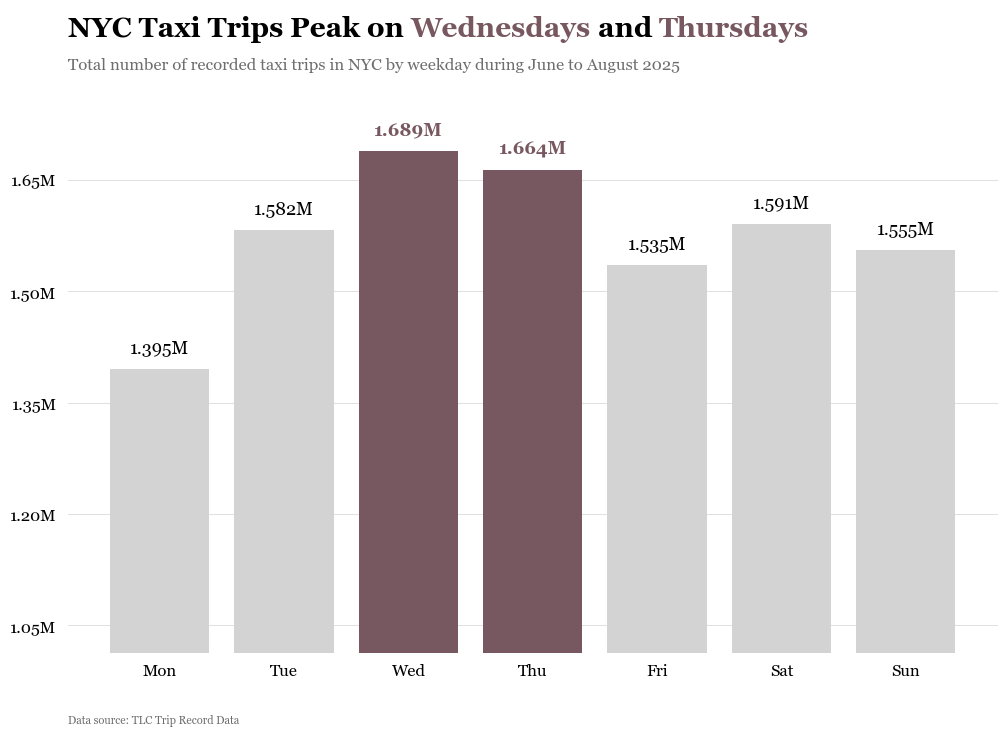

In [42]:
# define colour palette
cmap = load_cmap("groudon")
colours = cmap.colors
highlight_colour = colours[0]

# identify top 2 weekdays by number of trips
top2 = df.nlargest(2, "num_trips")
highlight_days = top2["pickup_weekday"].tolist()

# map colours: highlight top 2 days, mute others
colours_df = df["pickup_weekday"].isin(highlight_days).map({
    True: highlight_colour,
    False: "lightgrey"
})

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# refine appearance of axes
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(
    axis="both",
    length=0,
    pad=8,
    labelsize=12
)

# manually set y-axis limits
ax.set_ylim(
    df["num_trips"].max() * 0.6,    # lower bound
    df["num_trips"].max() * 1.03     # upper bound with padding
)

# limit number of y-axis ticks
ax.yaxis.set_major_locator(
    mticker.MaxNLocator(nbins=5)
)

# optional: add "M" suffix to y-axis tick labels (millions)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1_000_000:.2f}M")
)

# add horizontal gridlines
ax.grid(
    axis="y",
    color="lightgrey",
    linewidth=0.5
)

# plot bar chart
ax.bar(
    x=df["pickup_weekday"].str[:3],
    height=df["num_trips"],
    color=colours_df,
    zorder=2
)

# annotate each bar with values in millions
max_trips = df["num_trips"].max()
for i, (day, value) in enumerate(zip(df["pickup_weekday"], df["num_trips"])):
    ax.text(
        x=i,
        y=value + (max_trips * 0.01),
        s=f"{value / 1_000_000:.3f}M",
        va="bottom",
        ha="center",
        fontsize=13,
        weight="bold" if day in highlight_days else None,
        color=highlight_colour if day in highlight_days else "black"
    )

# chart title with top 2 highlighted weekdays
x_title, y_title = 0.125, 1.02
day1, day2 = highlight_days
fig_text(
    x=x_title, y=y_title,
    s=f"NYC Taxi Trips Peak on <{day1}s> and <{day2}s>",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# subtitle
fig.text(
    x=x_title, y=y_title * 0.925,
    s="Total number of recorded taxi trips in NYC by weekday during June to August 2025",
    size=12,
    color="#6e6e6e"
)

# data source caption
fig.text(
    x=x_title,
    y=0.005,
    s="Data source: TLC Trip Record Data",
    ha="left",
    va="bottom",
    fontsize=8,
    color="#6e6e6e"
)

# save figure
plt.savefig(
    "../images/trips_by_weekday.svg",
    bbox_inches="tight"
)

plt.show()